# Chapter 14: Gas Compression Systems

This notebook demonstrates gas compression concepts using NeqSim:
- Single-stage compressor power vs compression ratio
- Polytropic efficiency effects
- Multi-stage compression with intercooling
- Power comparison: single vs multi-stage
- Discharge temperature limits and why multi-staging is needed

Compression is typically the largest energy consumer in oil and gas processing facilities.

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch12_compression_figures.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# NeqSim class imports
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

## Helper: Create Feed Gas Stream

We define a standard lean gas feed for all compression studies.

In [3]:
def create_gas_feed(temp_C=30.0, press_bara=5.0, flow_kghr=50000.0):
    """Create a lean gas feed stream."""
    fluid = SystemSrkEos(273.15 + temp_C, press_bara)
    fluid.addComponent("methane", 0.88)
    fluid.addComponent("ethane", 0.06)
    fluid.addComponent("propane", 0.03)
    fluid.addComponent("n-butane", 0.01)
    fluid.addComponent("nitrogen", 0.01)
    fluid.addComponent("CO2", 0.01)
    fluid.setMixingRule("classic")

    feed = Stream("Gas Feed", fluid)
    feed.setFlowRate(flow_kghr, "kg/hr")
    feed.run()
    return feed

test_feed = create_gas_feed()
print(f"Feed: {float(test_feed.getTemperature('C')):.1f} °C, {float(test_feed.getPressure('bara')):.1f} bara")

Feed: 30.0 °C, 5.0 bara


## Figure 1: Compressor Power vs Compression Ratio

We compress the gas from 5 bara to increasing outlet pressures and measure power consumption.

Power at ratio 6.0 (η=0.75): 5.76 MW
Power at ratio 6.0 (η=0.85): 4.93 MW


ch12_compression_figures.ipynb:cell6:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


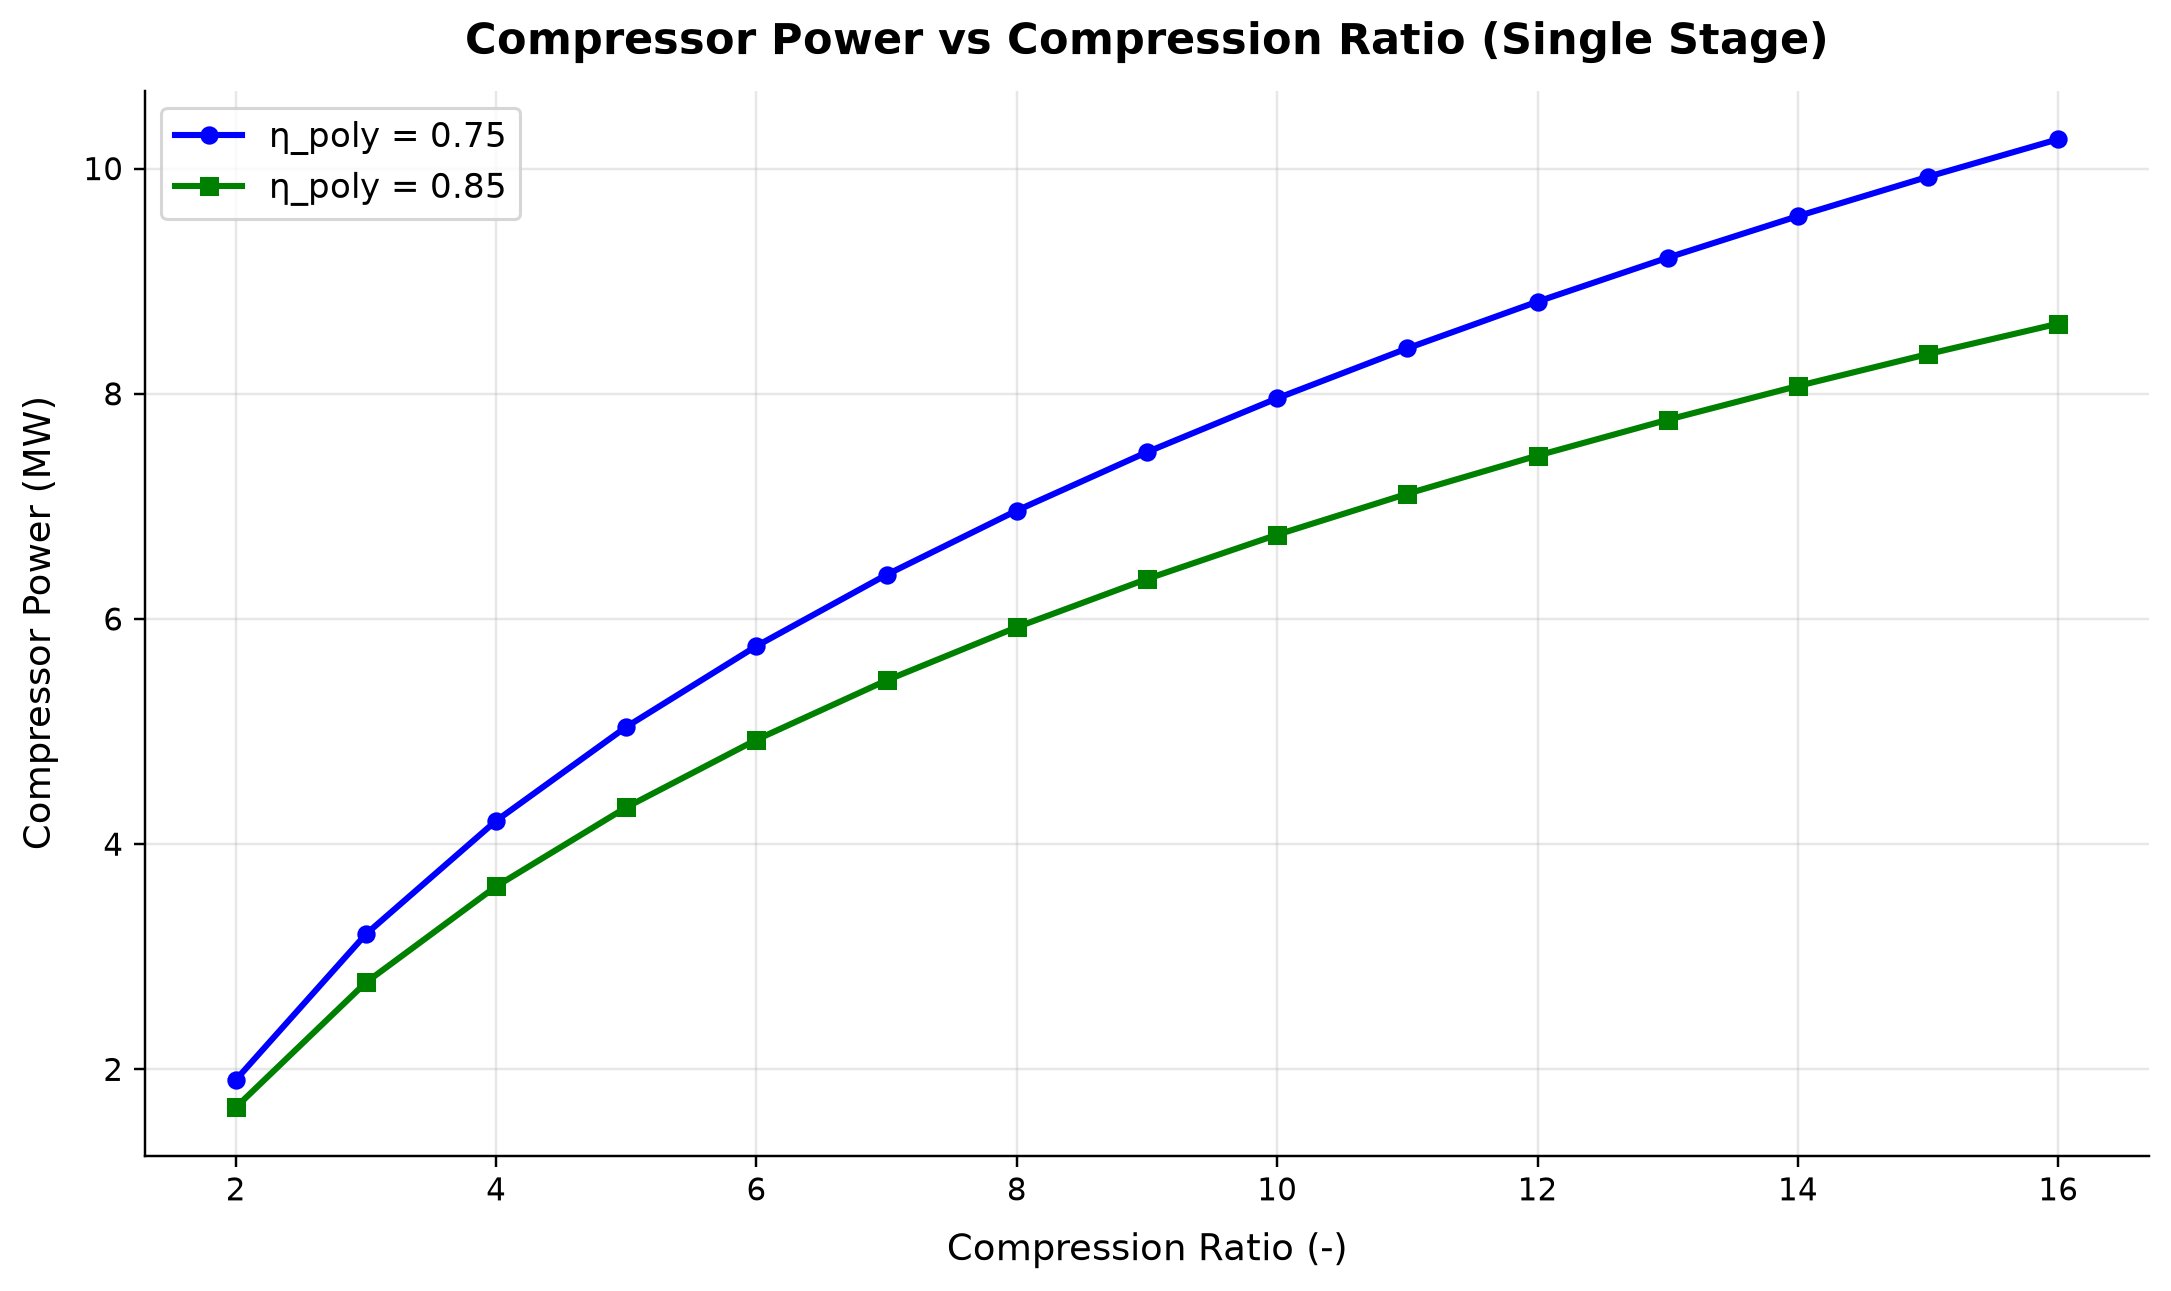

In [4]:
outlet_pressures = np.arange(10, 85, 5)
inlet_pressure = 5.0
compression_ratios = outlet_pressures / inlet_pressure
powers_75 = []
powers_85 = []
discharge_temps = []

for p_out in outlet_pressures:
    # Efficiency = 0.75
    feed75 = create_gas_feed(press_bara=inlet_pressure)
    comp75 = Compressor("comp75", feed75.getOutletStream())
    comp75.setOutletPressure(float(p_out))
    comp75.setUsePolytropicCalc(True)
    comp75.setPolytropicEfficiency(0.75)
    comp75.run()
    powers_75.append(float(comp75.getPower("kW")))
    discharge_temps.append(float(comp75.getOutletStream().getTemperature("C")))

    # Efficiency = 0.85
    feed85 = create_gas_feed(press_bara=inlet_pressure)
    comp85 = Compressor("comp85", feed85.getOutletStream())
    comp85.setOutletPressure(float(p_out))
    comp85.setUsePolytropicCalc(True)
    comp85.setPolytropicEfficiency(0.85)
    comp85.run()
    powers_85.append(float(comp85.getPower("kW")))

assert np.all(np.array(powers_75) > np.array(powers_85)), "Higher efficiency must lower power"

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(compression_ratios, [p/1000 for p in powers_75], 'b-o', linewidth=2, markersize=5,
        label='η_poly = 0.75')
ax.plot(compression_ratios, [p/1000 for p in powers_85], 'g-s', linewidth=2, markersize=5,
        label='η_poly = 0.85')

ax.set_xlabel('Compression Ratio (-)', fontsize=12)
ax.set_ylabel('Compressor Power (MW)', fontsize=12)
ax.set_title('Compressor Power vs Compression Ratio (Single Stage)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig12_1_power_vs_ratio.png', dpi=220, bbox_inches='tight')
plt.show()
print(f"Power at ratio 6.0 (η=0.75): {powers_75[4]/1000:.2f} MW")
print(f"Power at ratio 6.0 (η=0.85): {powers_85[4]/1000:.2f} MW")

**Executed-figure discussion.** Η_poly = 0.75: compressor power spans 1.906–10.26 MW across the plotted cases. Η_poly = 0.85: compressor power spans 1.662–8.623 MW across the plotted cases.

Increasing pressure ratio raises required specific compression work; lower polytropic efficiency increases both shaft demand and heating. A driver power limit and a discharge-temperature limit may constrain different parts of the same operating envelope. Activate polytropic calculation explicitly, check both limits at the actual gas composition and retain an ambient-dependent driver margin.


**Discussion:** Compressor power increases approximately proportionally to ln(compression ratio) for ideal gas, but real gas effects cause non-linear behavior at higher ratios. The 10 percentage-point improvement in polytropic efficiency gives significant power savings across all compression ratios, illustrating why efficiency optimization is critical for operating cost reduction.

## Figure 2: Polytropic Efficiency vs Flow Rate (Conceptual Compressor Curve)

We model how a compressor behaves at different flow rates by running at various mass flows,
showing the resulting head and efficiency relationships.

Figure saved: fig12_2_compressor_curve.png


ch12_compression_figures.ipynb:cell9:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


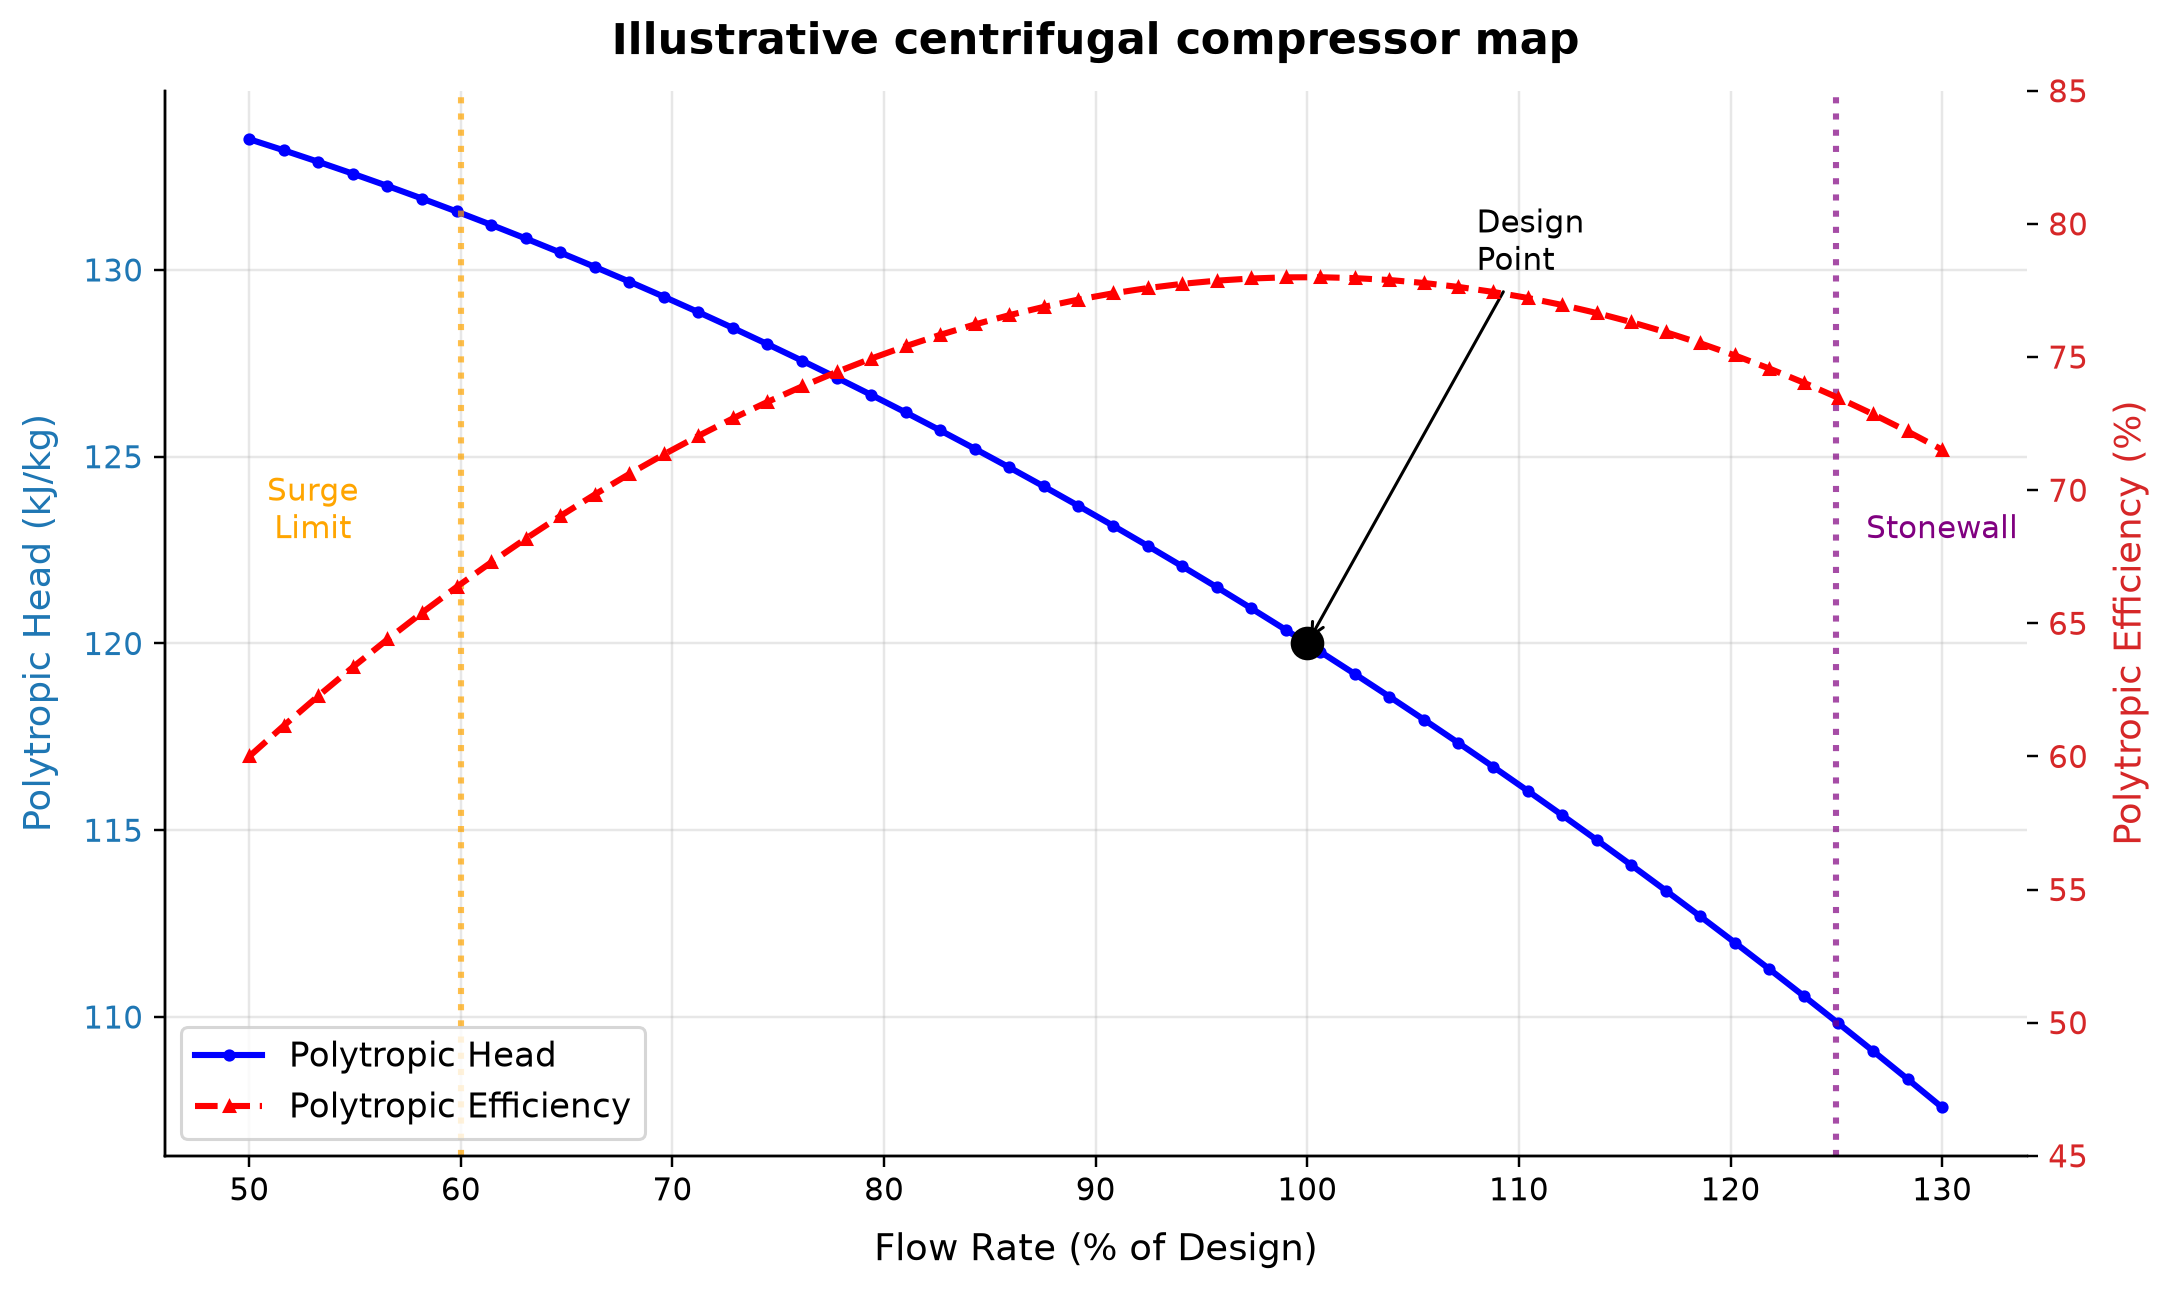

In [5]:
# Compressor performance map — conceptual curves for centrifugal compressor
# Based on typical centrifugal compressor characteristics (API 617)
flow_pct = np.linspace(50, 130, 50)  # % of design flow

# Head curve: quadratic drop from surge to stonewall
design_head = 120.0  # kJ/kg at 100% flow
head_curve = design_head * (1.0 + 0.15 * (1.0 - (flow_pct / 100.0)**2))
head_curve = np.clip(head_curve, 20, 160)

# Efficiency curve: parabolic peak at design point (~100% flow)
peak_eff = 0.78
eff_curve = peak_eff - 0.18 * ((flow_pct - 100) / 50)**2
eff_curve = np.clip(eff_curve, 0.50, peak_eff)

# Power curve: proportional to flow * head / efficiency
power_curve = flow_pct / 100 * head_curve / eff_curve
power_normalized = power_curve / power_curve[len(power_curve)//2] * 100  # normalize to design

fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'tab:blue'
ax1.plot(flow_pct, head_curve, 'b-o', linewidth=2, markersize=3, label='Polytropic Head')
ax1.set_xlabel('Flow Rate (% of Design)', fontsize=12)
ax1.set_ylabel('Polytropic Head (kJ/kg)', fontsize=12, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.plot(flow_pct, eff_curve * 100, 'r--^', linewidth=2, markersize=3,
         label='Polytropic Efficiency')
ax2.set_ylabel('Polytropic Efficiency (%)', fontsize=12, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(45, 85)

# Mark surge and choke regions
ax1.axvline(x=60, color='orange', linestyle=':', linewidth=2, alpha=0.7)
ax1.text(53, max(head_curve)*0.92, 'Surge\nLimit', fontsize=10, color='orange', ha='center')
ax1.axvline(x=125, color='purple', linestyle=':', linewidth=2, alpha=0.7)
ax1.text(130, max(head_curve)*0.92, 'Stonewall', fontsize=10, color='purple', ha='center')

# Design point
ax1.plot(100, design_head, 'ko', markersize=10, zorder=5)
ax1.annotate('Design\nPoint', xy=(100, design_head), xytext=(108, design_head+10),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='black'))

ax1.set_title('Illustrative centrifugal compressor map', fontsize=14)
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig12_2_compressor_curve.png', dpi=220, bbox_inches='tight')
plt.show()
print("Figure saved: fig12_2_compressor_curve.png")

**Executed-figure discussion.** Polytropic Head spans 107.6–133.5 kJ/kg across the plotted cases. Polytropic Efficiency spans 60–78 % across the plotted cases.

A compressor map relates head and efficiency to inlet volume and rotational speed; the plotted map is an illustrative performance model. Synthetic curve shape cannot establish a real machine’s surge line, choke limit or guaranteed efficiency. Replace the teaching map with a vendor or validated test map, including its flow, head, efficiency and correction-condition definitions.


**Discussion:** The compressor performance map shows the operating envelope bounded by surge (low flow, dynamic instability) and stonewall/choke (high flow, sonic velocity). Efficiency peaks near the design point and falls off at both extremes. Operating a compressor away from its design point significantly increases specific energy consumption, making flow control and recycle strategies important for optimization.

## Figure 3: Multi-Stage Compression with Intercooling

3-stage compression from 5 to 150 bara with intercooling to 40 °C after each stage.

Ratio per stage: 3.11
Total power: 9.99 MW

Equipment                T (°C)   P (bara)   Power (kW)
-------------------------------------------------------
Feed                       30.0        5.0            0
Comp 1 Outlet             137.7       15.5         3320
IC 1 Outlet                40.0       15.5            0
Comp 2 Outlet             150.8       48.3         3380
IC 2 Outlet                40.0       48.3            0
Comp 3 Outlet             152.8      150.0         3293


ch12_compression_figures.ipynb:cell12:91: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


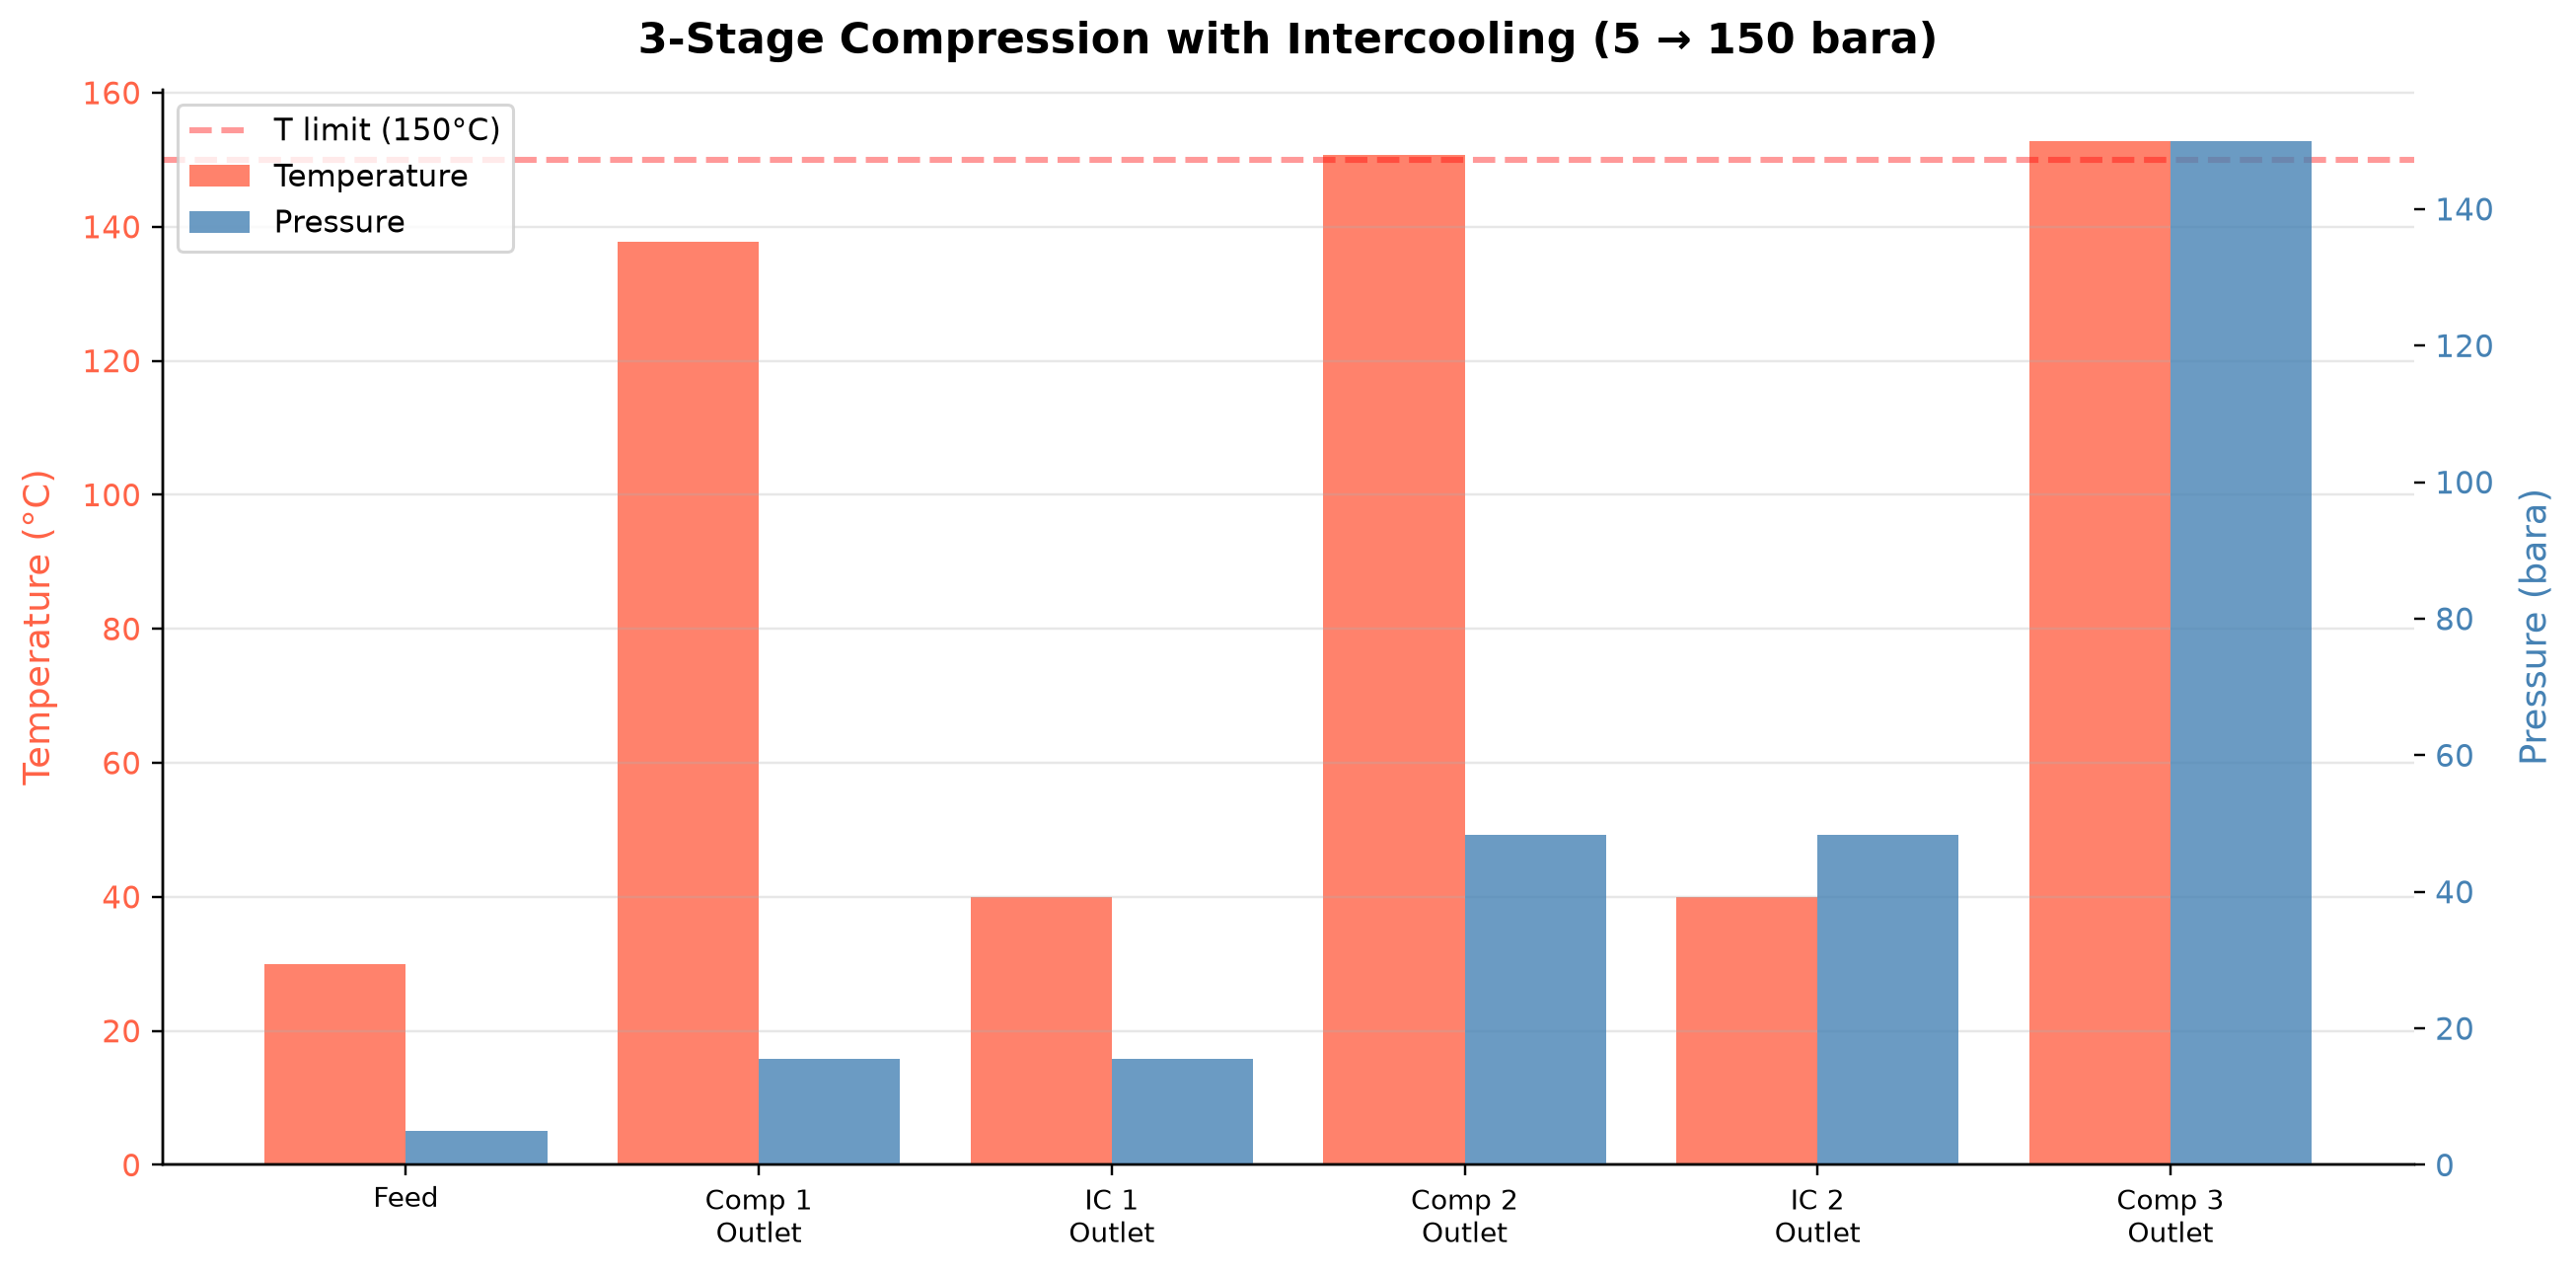

In [6]:
# 3-stage compression: 5 → 17 → 51 → 150 bara (equal ratio ~ 3.0)
p_in = 5.0
p_out = 150.0
n_stages = 3
ratio_per_stage = (p_out / p_in) ** (1.0 / n_stages)
intercool_temp_C = 40.0

feed = create_gas_feed(temp_C=30.0, press_bara=p_in)

stage_data = []
stage_data.append({
    'label': 'Feed',
    'T_C': float(feed.getOutletStream().getTemperature('C')),
    'P_bara': float(feed.getOutletStream().getPressure('bara')),
    'power_kW': 0
})

current_stream = feed.getOutletStream()
total_power = 0.0

for i in range(n_stages):
    stage_p_out = p_in * ratio_per_stage ** (i + 1)

    comp = Compressor(f"Stage {i+1}", current_stream)
    comp.setOutletPressure(stage_p_out)
    comp.setUsePolytropicCalc(True)
    comp.setPolytropicEfficiency(0.75)
    comp.run()

    comp_power = float(comp.getPower('kW'))
    total_power += comp_power

    stage_data.append({
        'label': f'Comp {i+1}\nOutlet',
        'T_C': float(comp.getOutletStream().getTemperature('C')),
        'P_bara': float(comp.getOutletStream().getPressure('bara')),
        'power_kW': comp_power
    })

    if i < n_stages - 1:  # Intercooler (not after last stage)
        cooler = Cooler(f"IC {i+1}", comp.getOutletStream())
        cooler.setOutTemperature(273.15 + intercool_temp_C)
        cooler.run()

        stage_data.append({
            'label': f'IC {i+1}\nOutlet',
            'T_C': float(cooler.getOutletStream().getTemperature('C')),
            'P_bara': float(cooler.getOutletStream().getPressure('bara')),
            'power_kW': 0
        })
        current_stream = cooler.getOutletStream()
    else:
        current_stream = comp.getOutletStream()

print(f"Ratio per stage: {ratio_per_stage:.2f}")
print(f"Total power: {total_power/1000:.2f} MW")
print(f"\n{'Equipment':20s} {'T (°C)':>10s} {'P (bara)':>10s} {'Power (kW)':>12s}")
print("-" * 55)
for d in stage_data:
    print(f"{d['label'].replace(chr(10),' '):20s} {d['T_C']:10.1f} {d['P_bara']:10.1f} {d['power_kW']:12.0f}")

# Plot
labels = [d['label'] for d in stage_data]
temps = [d['T_C'] for d in stage_data]
press = [d['P_bara'] for d in stage_data]

fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(labels))

ax1.bar(x - 0.2, temps, 0.4, color='tomato', alpha=0.8, label='Temperature')
ax1.set_ylabel('Temperature (°C)', fontsize=12, color='tomato')
ax1.tick_params(axis='y', labelcolor='tomato')

ax2 = ax1.twinx()
ax2.bar(x + 0.2, press, 0.4, color='steelblue', alpha=0.8, label='Pressure')
ax2.set_ylabel('Pressure (bara)', fontsize=12, color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_title('3-Stage Compression with Intercooling (5 → 150 bara)', fontsize=14)
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=150, color='red', linestyle='--', alpha=0.4, label='T limit (150°C)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig12_3_multistage_profile.png', dpi=220, bbox_inches='tight')
plt.show()

**Executed-figure discussion.** Temperature spans 30–152.8 °C across the plotted cases. Pressure spans 5–150 bara across the plotted cases.

Each compressor raises gas temperature, while intercooling lowers the inlet temperature and specific work of the following stage. The highest stage discharge temperature, rather than the final cooled outlet, must meet the thermal limit; the updated three-stage example slightly exceeds the illustrative 150°C limit. Adjust stage count, intermediate pressures or cooling conditions and recheck every stage before accepting the train configuration.


**Discussion:** The temperature saw-tooth pattern shows how intercooling keeps the gas within acceptable temperature limits. Each compressor stage raises the temperature significantly, and the intercooler brings it back to 40 °C. Without intercooling, a single stage from 5 to 150 bara would produce extremely high discharge temperatures, exceeding material limits. The equal pressure ratio per stage ensures balanced power distribution.

## Figure 4: Power Comparison — Single vs Multi-Stage

We compare total compression power for the same overall ratio (5 → 150 bara) using 1, 2, 3, and 4 stages.

1 stages: Power = 13.86 MW, Max T = 401 °C, Ratio/stage = 30.00
2 stages: Power = 10.93 MW, Max T = 215 °C, Ratio/stage = 5.48
3 stages: Power = 9.99 MW, Max T = 153 °C, Ratio/stage = 3.11
4 stages: Power = 9.54 MW, Max T = 122 °C, Ratio/stage = 2.34


ch12_compression_figures.ipynb:cell15:74: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


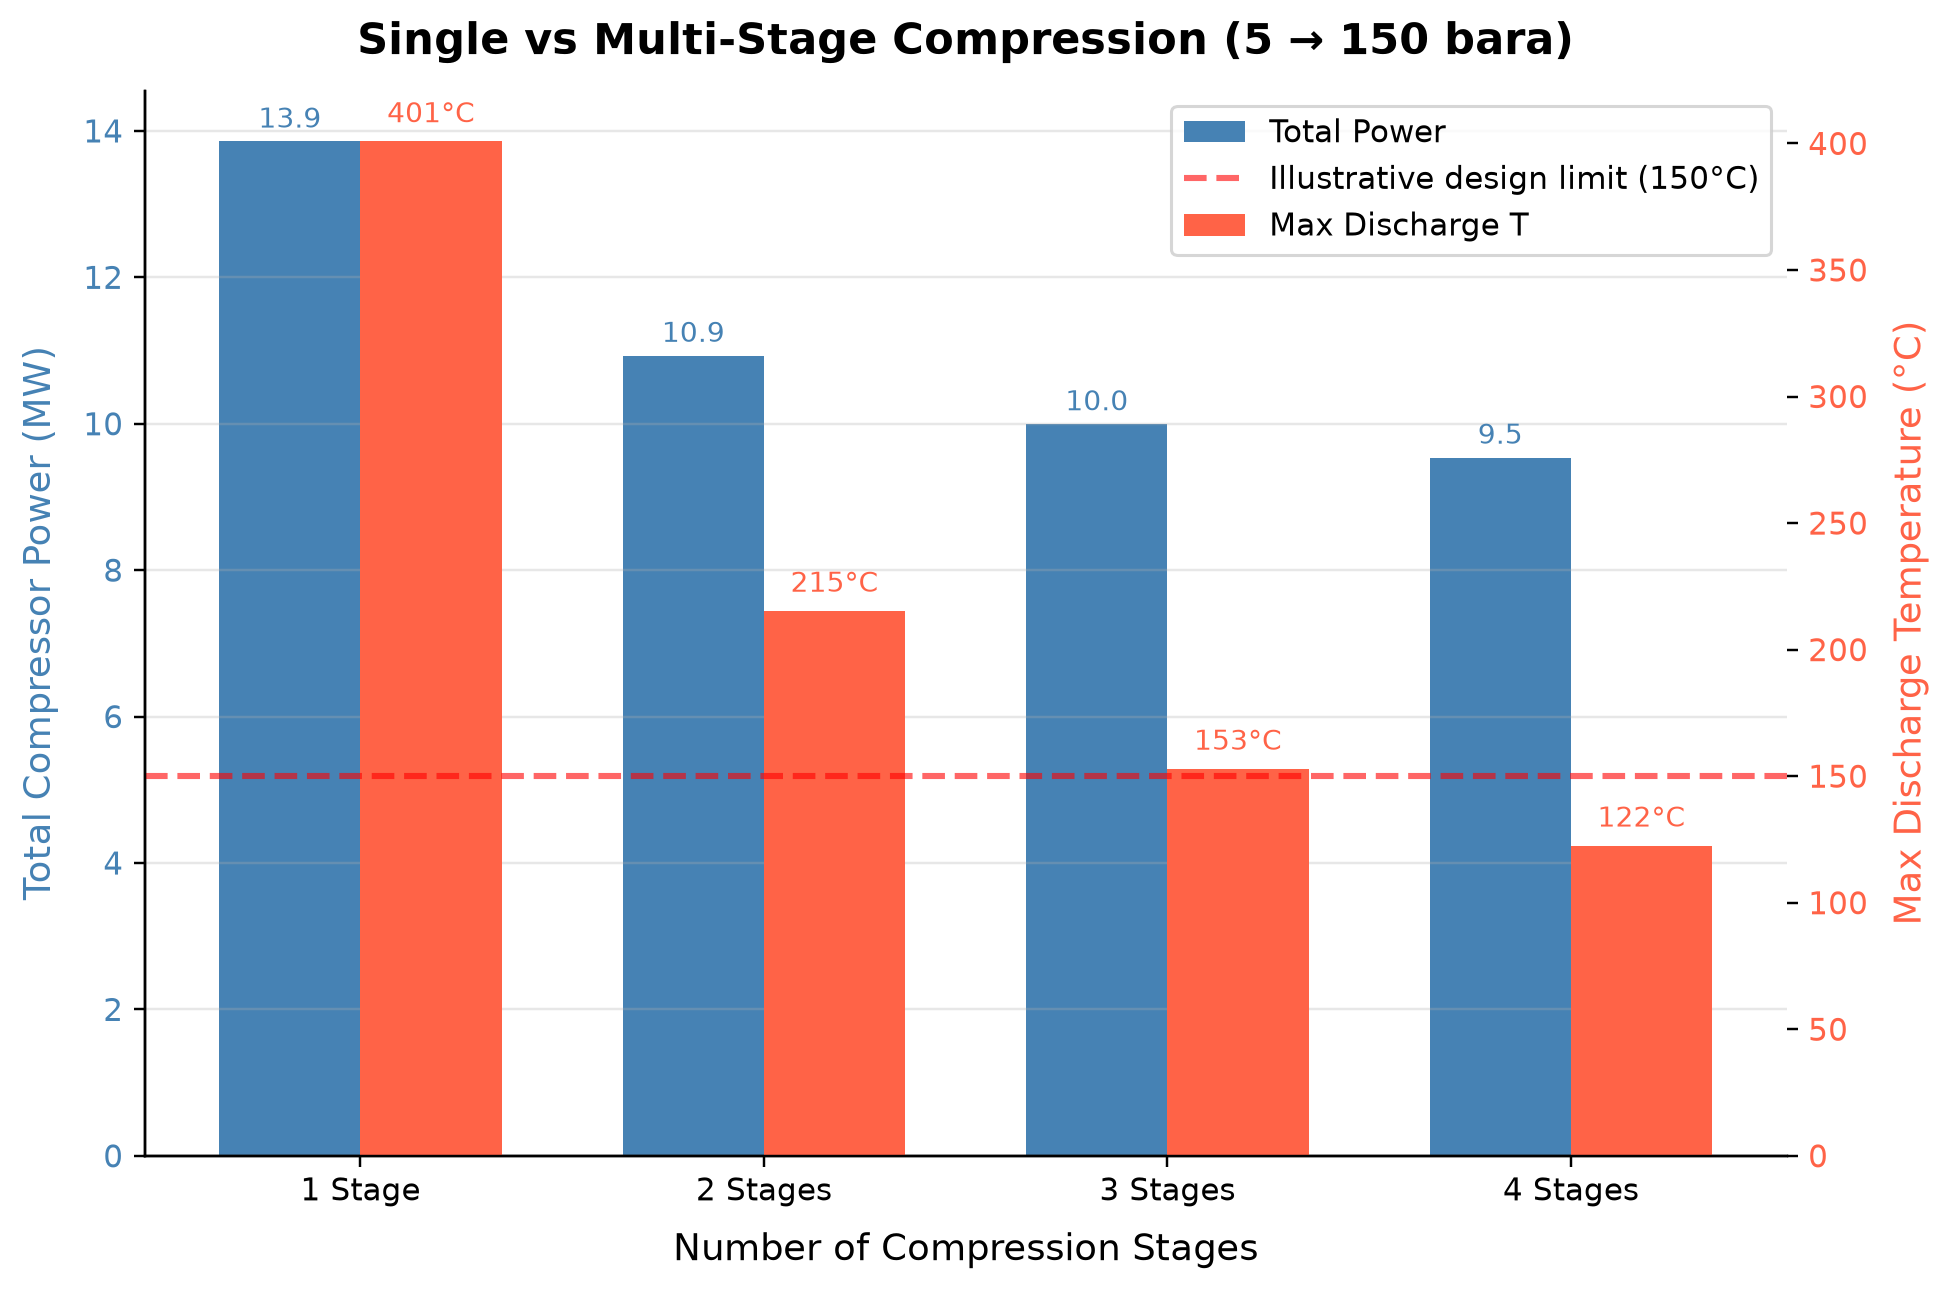

In [7]:
p_in = 5.0
p_final = 150.0
stage_counts = [1, 2, 3, 4]
total_powers = []
max_discharge_temps = []

for n in stage_counts:
    ratio = (p_final / p_in) ** (1.0 / n)

    feed = create_gas_feed(temp_C=30.0, press_bara=p_in)
    current_stream = feed.getOutletStream()
    total_pwr = 0.0
    max_t = 0.0

    for i in range(n):
        stage_p = p_in * ratio ** (i + 1)
        comp = Compressor(f"S{i+1}", current_stream)
        comp.setOutletPressure(stage_p)
        comp.setUsePolytropicCalc(True)
        comp.setPolytropicEfficiency(0.75)
        comp.run()

        total_pwr += float(comp.getPower('kW'))
        t_out = float(comp.getOutletStream().getTemperature('C'))
        max_t = max(max_t, t_out)

        if i < n - 1:
            cooler = Cooler(f"IC{i+1}", comp.getOutletStream())
            cooler.setOutTemperature(273.15 + 40.0)
            cooler.run()
            current_stream = cooler.getOutletStream()
        else:
            current_stream = comp.getOutletStream()

    total_powers.append(total_pwr / 1000)  # MW
    max_discharge_temps.append(max_t)
    print(f"{n} stages: Power = {total_pwr/1000:.2f} MW, Max T = {max_t:.0f} °C, Ratio/stage = {ratio:.2f}")

fig, ax1 = plt.subplots(figsize=(9, 6))

x = np.arange(len(stage_counts))
width = 0.35

bars1 = ax1.bar(x - width/2, total_powers, width, color='steelblue', label='Total Power')
ax1.set_ylabel('Total Compressor Power (MW)', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, max_discharge_temps, width, color='tomato', label='Max Discharge T')
ax2.set_ylabel('Max Discharge Temperature (°C)', fontsize=12, color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.axhline(y=150, color='red', linestyle='--', alpha=0.6, label='Illustrative design limit (150°C)')

ax1.set_xlabel('Number of Compression Stages', fontsize=12)
ax1.set_title('Single vs Multi-Stage Compression (5 → 150 bara)', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels([f'{n} Stage{"s" if n > 1 else ""}' for n in stage_counts])
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars1, total_powers):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9, color='steelblue')
for bar, val in zip(bars2, max_discharge_temps):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.0f}°C', ha='center', va='bottom', fontsize=9, color='tomato')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig12_4_power_comparison.png', dpi=220, bbox_inches='tight')
plt.show()

**Executed-figure discussion.** For the 5–150 bara train, one and four stages require 13.855 and 9.537 MW. Their maximum discharge temperatures are 400.8 and 122.5 °C. Three stages reach 152.8 °C, slightly above the illustrative 150 °C limit.

Intercooling reduces the average specific volume during compression and therefore lowers total work relative to one hot compression step. The power benefit has diminishing returns and must be weighed against additional equipment, pressure losses and maintenance. Compare stage alternatives with consistent efficiency and cooling assumptions, then include total driver power, temperature limits and lifecycle cost.


**Discussion:** Multi-staging reduces total power consumption because intercooling brings the gas closer to isothermal compression (thermodynamic minimum work). The power saving from 1 to 2 stages is dramatic, with diminishing returns for 3+ stages. Equally important, multi-staging keeps discharge temperatures within material limits — single-stage compression at a ratio of 30 produces extreme temperatures that would damage seals and lubricants.

## Figure 5: Discharge Temperature vs Compression Ratio

This figure shows why single-stage compression is impractical at high ratios.

150°C limit exceeded at ratio 4.0 (η=0.75): T = 164°C


ch12_compression_figures.ipynb:cell18:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


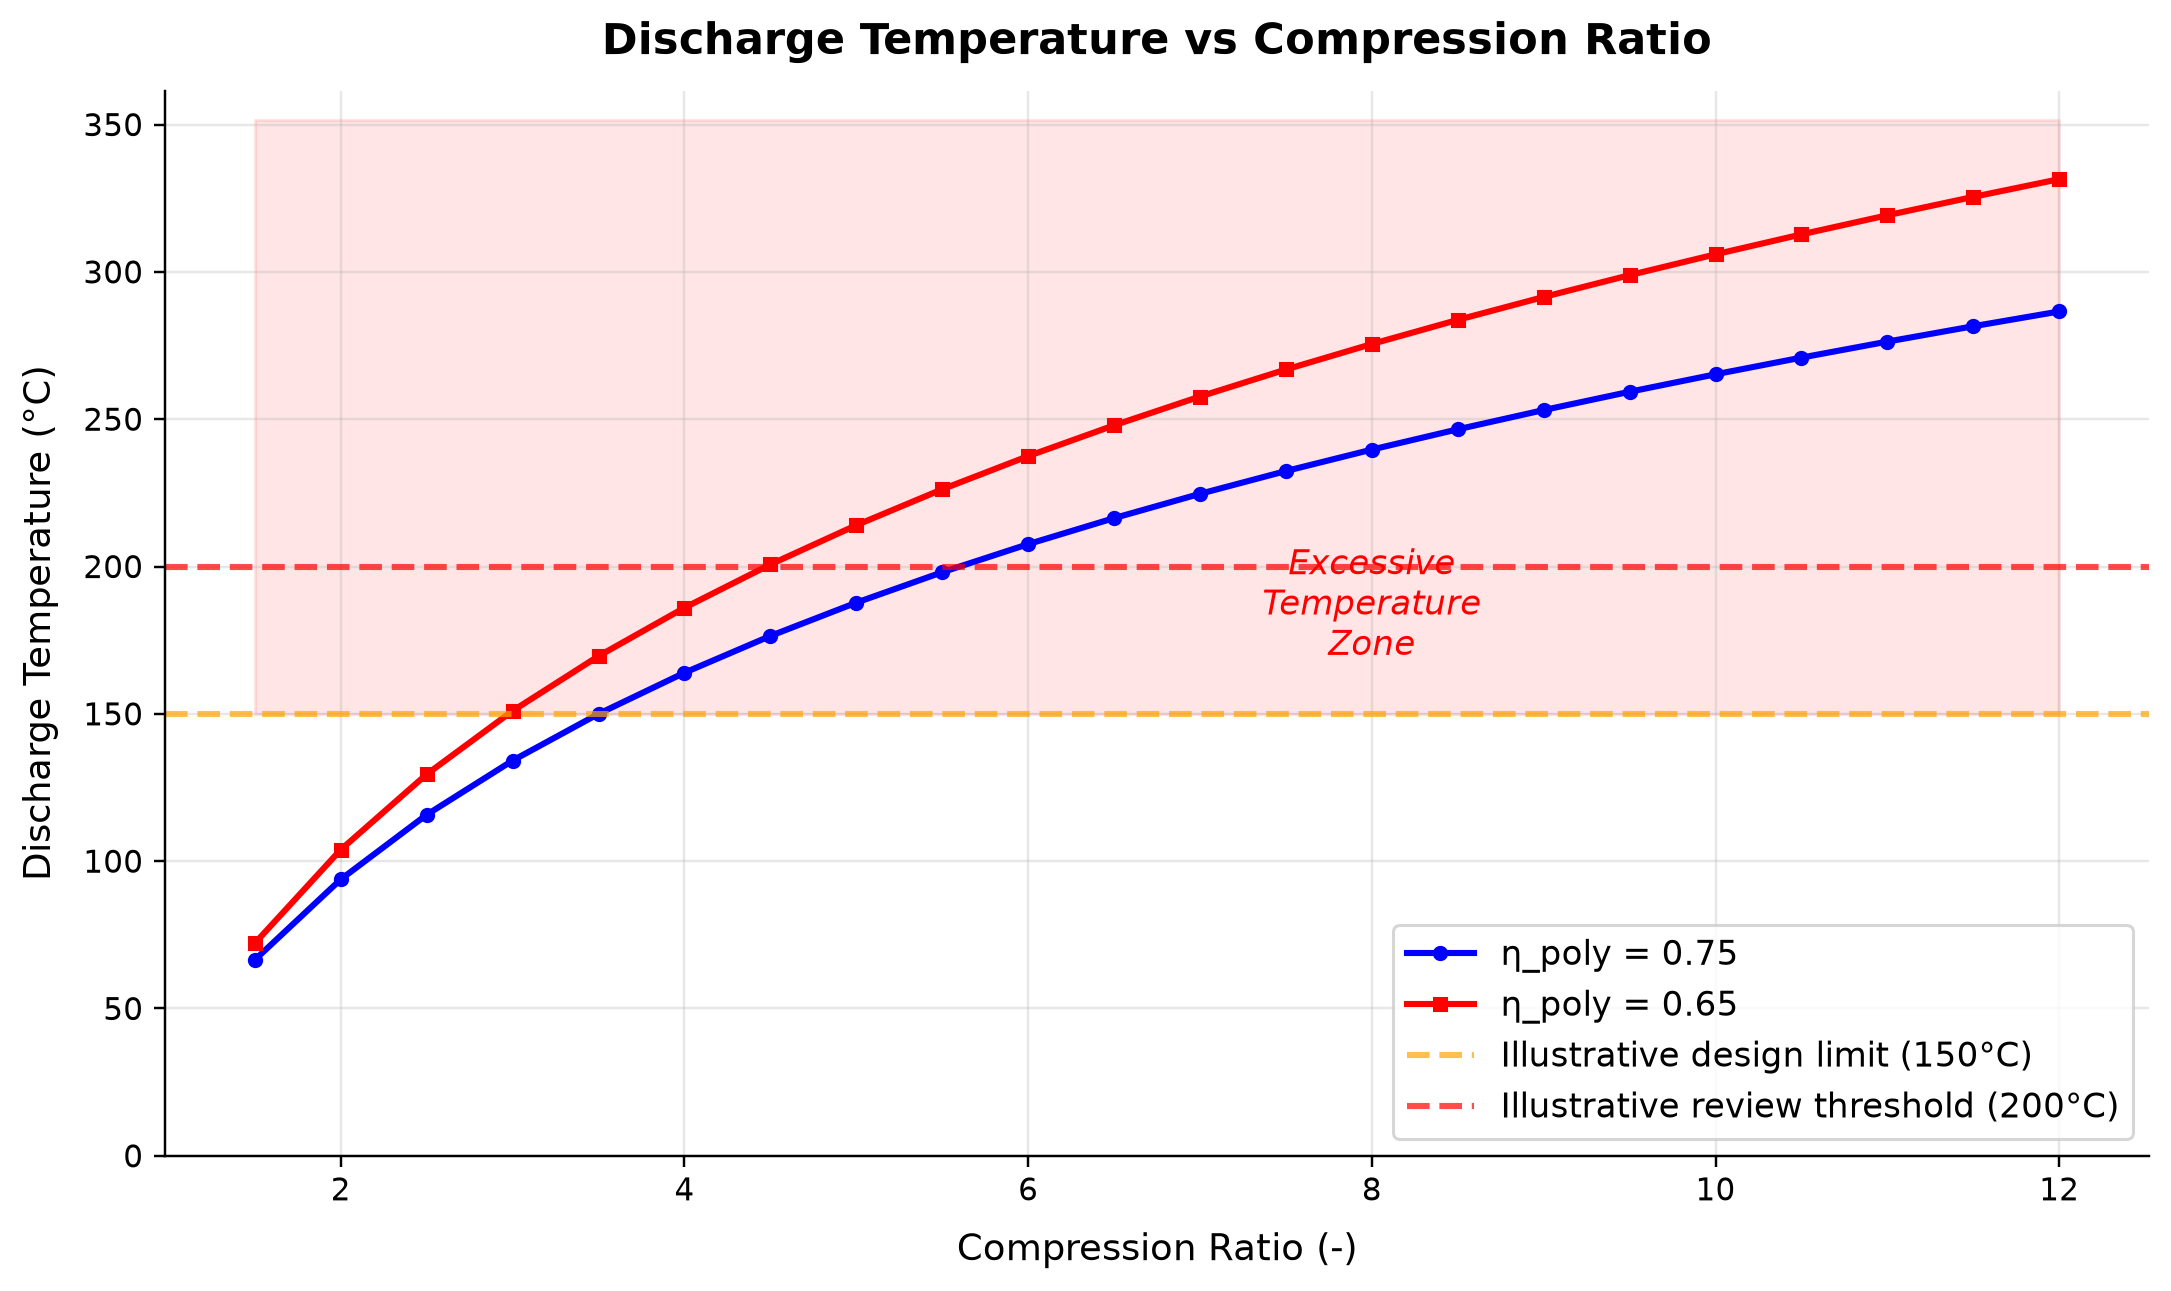

In [8]:
comp_ratios = np.arange(1.5, 12.5, 0.5)
discharge_temps_75 = []
discharge_temps_65 = []

for cr in comp_ratios:
    p_out = 5.0 * float(cr)

    # eta = 0.75
    feed75 = create_gas_feed(temp_C=30.0, press_bara=5.0)
    comp75 = Compressor("c75", feed75.getOutletStream())
    comp75.setOutletPressure(p_out)
    comp75.setUsePolytropicCalc(True)
    comp75.setPolytropicEfficiency(0.75)
    comp75.run()
    discharge_temps_75.append(float(comp75.getOutletStream().getTemperature('C')))

    # eta = 0.65
    feed65 = create_gas_feed(temp_C=30.0, press_bara=5.0)
    comp65 = Compressor("c65", feed65.getOutletStream())
    comp65.setOutletPressure(p_out)
    comp65.setUsePolytropicCalc(True)
    comp65.setPolytropicEfficiency(0.65)
    comp65.run()
    discharge_temps_65.append(float(comp65.getOutletStream().getTemperature('C')))

assert np.all(np.array(discharge_temps_65) > np.array(discharge_temps_75)), "Lower efficiency must raise discharge temperature"

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(comp_ratios, discharge_temps_75, 'b-o', linewidth=2, markersize=4, label='η_poly = 0.75')
ax.plot(comp_ratios, discharge_temps_65, 'r-s', linewidth=2, markersize=4, label='η_poly = 0.65')

# Material limits
ax.axhline(y=150, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Illustrative design limit (150°C)')
ax.axhline(y=200, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Illustrative review threshold (200°C)')

# Shade danger zone
ax.fill_between(comp_ratios, 150, max(max(discharge_temps_75), max(discharge_temps_65)) + 20,
                alpha=0.1, color='red')
ax.text(8, 170, 'Excessive\nTemperature\nZone', fontsize=11, color='red', ha='center', style='italic')

ax.set_xlabel('Compression Ratio (-)', fontsize=12)
ax.set_ylabel('Discharge Temperature (°C)', fontsize=12)
ax.set_title('Discharge Temperature vs Compression Ratio', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, max(max(discharge_temps_75), max(discharge_temps_65)) + 30)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig12_5_discharge_temperature.png', dpi=220, bbox_inches='tight')
plt.show()

# Find max safe ratio
for i, t in enumerate(discharge_temps_75):
    if t > 150:
        print(f"150°C limit exceeded at ratio {comp_ratios[i]:.1f} (η=0.75): T = {t:.0f}°C")
        break

**Executed-figure discussion.** Η_poly = 0.75: discharge temperature spans 66.52–286.6 °C across the plotted cases. Η_poly = 0.65: discharge temperature spans 72.16–331.5 °C across the plotted cases.

Compression converts shaft work into fluid enthalpy; a lower efficiency produces a larger temperature rise for the same pressure ratio. A feasible pressure target may still require another stage or more effective intercooling because of material, lubricant or process-temperature limits. Apply the project-specific temperature limit to every operating and degradation case, rather than treating 150°C as a universal machine limit.


**Discussion:** Discharge temperature increases rapidly with compression ratio, especially at lower efficiencies. The typical design limit of 150 °C restricts single-stage ratios to approximately 3-4 for natural gas. Beyond this, multi-staging with intercooling is mandatory. Lower efficiency compressors (worn seals, fouled internals) reach the temperature limit at even lower ratios, which is why degraded equipment must sometimes reduce throughput.

## Summary

Key takeaways from gas compression systems:

1. **Power consumption** scales with compression ratio and is strongly affected by polytropic efficiency
2. **Compressor curves** define the operating envelope — bounded by surge and stonewall limits
3. **Multi-stage compression** with intercooling reduces both power consumption and discharge temperature
4. **Equal pressure ratio** per stage provides balanced power distribution and optimal efficiency
5. **Discharge temperature** limits single-stage ratios to ~3-4; higher ratios require multi-staging

These principles govern the design of gas recompression, export compression, and gas injection systems.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [9]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                           Figure  Panel                                Series                  Output / unit  Minimum  Maximum  Finite points  Missing points
       fig12_1_power_vs_ratio.png      1                         η_poly = 0.75          Compressor Power (MW)  1.90615  10.2611             15               0
       fig12_1_power_vs_ratio.png      1                         η_poly = 0.85          Compressor Power (MW)  1.66208  8.62288             15               0
     fig12_2_compressor_curve.png      1                       Polytropic Head        Polytropic Head (kJ/kg)   107.58    133.5             50               0
     fig12_2_compressor_curve.png      1                               Curve 2        Polytropic Head (kJ/kg)        0        1              2               0
     fig12_2_compressor_curve.png      1                               Curve 3        Polytropic Head (kJ/kg)        0        1              2               0
     fig12_2_compressor_curve.png      1      